# E03 Matrix Sensing Ablations

### Problem

This notebook is a Matrix Sensing ablation study. It starts from the E01 sensing model

$$y_i=\langle A_i,X^\star\rangle+\xi_i,\qquad f_s(X)=\frac{1}{2m}\sum_{i=1}^{m}(\langle A_i^{(s)},X\rangle-y_i^{(s)})^2,$$

and changes one modeling assumption at a time. The target matrix is

$$X^\star=U\operatorname{diag}(s_1,\ldots,s_d)V^\top,$$

where $U,V$ are QR factors of independent Gaussian matrices. The code supports `hard-cutoff`, `polynomial-decay`, and `exponential-decay` spectra. For `kappa=1`, the nonzero singular values are respectively $1$, $1/j$, and $\exp(-0.5(j-1))$ for $j\le r$. When `kappa>1`, the first $r$ singular values are replaced by a linear grid from $1$ to $1/\kappa$.

The measurement distribution is controlled by `dist`. This notebook uses `normal`, `rademacher`, and `sphere`, corresponding to Gaussian entries, independent $\pm1$ entries, and normalized Gaussian sensing matrices $A_i=B_i/\lVert B_i\rVert_F$. Noise is $\xi_i=\sigma\eta_i$ with $\eta_i\overset{\mathrm{i.i.d.}}{\sim}\mathcal{N}(0,1)$, and the direct initialization is

$$X_0=s_{\mathrm{init}}G_0,\qquad G_0[j,k]\overset{\mathrm{i.i.d.}}{\sim}\mathcal{N}(0,1),\qquad s_{\mathrm{init}}=10^{-2}.$$

The experiment fixes $d=60$, $r=5$, $m=2dr$, initialization scale, and optimizer grid; its scenarios vary measurement law, spectrum, condition number $\kappa$, or noise scale $\sigma$. Its purpose is to identify which assumptions actually change optimization behavior and which changes are minor relative to optimizer choice.

When reading the results, focus first on scenario-by-optimizer final/minimum loss, then inspect scenario log-loss curves for convergence differences. This notebook primarily measures training loss, not recovery error, so read it together with E05 and E06 before making statistical recovery claims. Each step costs $\Theta(md^2)=\Theta(2rd^3)$, and the full grid can execute up to $7000000$ optimization steps.

## Implementation Details: Skip Unless Modifying The Experiment

The code below is visible for reproducibility. A reader can skip it unless changing the grid, optimizer definitions, stopping rule, diagnostics, or plotting calls.

In [1]:
import os
import pathlib
import sys
import time
for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import joblib
import IPython.display
import matplotlib.pyplot as plt
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import plotting
import problems.MatrixConstruction
import problems.MatrixFactorization
import problems.MatrixSensing
import util

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")
print(f"joblib  = {joblib.__version__}")


project = /Users/tianyangliu/Desktop/muonexperiment
torch   = 2.11.0
joblib  = 1.4.2


/opt/anaconda3/envs/muonexperiment-torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Parameters And Grid Preview

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = ["Muon", "Muon-Exact", "Shampoo", "Adam", "SGD"]
SEEDS = list(range(100))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 2000

BASE_SPEC = dict(
    d=60,
    rank=5,
    lr=0.01,
    init_scale=0.01,
    iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
    early_stop=True,
    early_stop_min_steps=20,
    early_stop_patience=20,
    early_stop_min_delta=1e-3,
    device_type=DEVICE.type,
    dtype_name=DTYPE_NAME,
)
SCENARIOS = [
    dict(scenario="baseline-normal", dist="normal", spectrum="hard-cutoff", kappa=1.0, noise=0.0),
    dict(scenario="rademacher-meas", dist="rademacher", spectrum="hard-cutoff", kappa=1.0, noise=0.0),
    dict(scenario="sphere-meas", dist="sphere", spectrum="hard-cutoff", kappa=1.0, noise=0.0),
    dict(scenario="polynomial-spectrum", dist="normal", spectrum="polynomial-decay", kappa=1.0, noise=0.0),
    dict(scenario="exponential-spectrum", dist="normal", spectrum="exponential-decay", kappa=1.0, noise=0.0),
    dict(scenario="kappa-100", dist="normal", spectrum="hard-cutoff", kappa=100.0, noise=0.0),
    dict(scenario="noise-0.01", dist="normal", spectrum="hard-cutoff", kappa=1.0, noise=0.01),
]
SCENARIO_ORDER = [scenario["scenario"] for scenario in SCENARIOS]
NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([
    {**BASE_SPEC, **scenario, "algo": algo, "seed": seed}
    for scenario in SCENARIOS
    for algo in ALGOS
    for seed in SEEDS
])
runs["problem"] = "MatrixSensing"
runs.insert(0, "run_id", range(len(runs)))
runs["scenario"] = pd.Categorical(runs["scenario"], categories=SCENARIO_ORDER, ordered=True)
preview_cols = [
    "run_id", "scenario", "problem", "algo", "d", "rank", "seed", "lr", "iters",
    "early_stop", "early_stop_min_steps", "early_stop_patience", "early_stop_min_delta",
    "noise", "dist", "spectrum", "kappa", "init_scale", "device_type", "dtype_name",
]
runs = runs[preview_cols]
runs["scenario"] = runs["scenario"].astype(str)

print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"smoke_test={SMOKE_TEST}, smoke_test_max_steps={SMOKE_TEST_MAX_STEPS}")
print(f"scenarios={len(SCENARIOS)}, runs={len(runs)}, max_iters={BASE_SPEC['iters']}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
print(
    "early_stop=patience on absolute loss improvement "
    f"(min_steps={BASE_SPEC['early_stop_min_steps']}, "
    f"patience={BASE_SPEC['early_stop_patience']}, "
    f"min_delta={BASE_SPEC['early_stop_min_delta']})"
)
IPython.display.display(pd.DataFrame(SCENARIOS))
IPython.display.display(runs)


device=cpu, workers=8, backend=loky
smoke_test=False, smoke_test_max_steps=10
scenarios=7, runs=350, max_iters=2000, max_total_steps=700000
early_stop=patience on absolute loss improvement (min_steps=20, patience=20, min_delta=0.001)


,scenario,dist,spectrum,kappa,noise
0,baseline-normal,normal,hard-cutoff,1.0,0.00
1,rademacher-meas,rademacher,hard-cutoff,1.0,0.00
2,sphere-meas,sphere,hard-cutoff,1.0,0.00
3,polynomial-spectrum,normal,polynomial-decay,1.0,0.00
4,exponential-spectrum,normal,exponential-decay,1.0,0.00
5,kappa-100,normal,hard-cutoff,100.0,0.00
6,noise-0.01,normal,hard-cutoff,1.0,0.01


,run_id,scenario,problem,algo,d,rank,seed,lr,iters,early_stop,early_stop_min_steps,early_stop_patience,early_stop_min_delta,noise,dist,spectrum,kappa,init_scale,device_type,dtype_name
0,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,20,20,0.001,0.00,normal,hard-cutoff,1.0,0.01,cpu,float64
1,1,baseline-normal,MatrixSensing,Muon,60,5,1,0.01,2000,True,20,20,0.001,0.00,normal,hard-cutoff,1.0,0.01,cpu,float64
2,2,baseline-normal,MatrixSensing,Muon,60,5,2,0.01,2000,True,20,20,0.001,0.00,normal,hard-cutoff,1.0,0.01,cpu,float64
3,3,baseline-normal,MatrixSensing,Muon,60,5,3,0.01,2000,True,20,20,0.001,0.00,normal,hard-cutoff,1.0,0.01,cpu,float64
4,4,baseline-normal,MatrixSensing,Muon,60,5,4,0.01,2000,True,20,20,0.001,0.00,normal,hard-cutoff,1.0,0.01,cpu,float64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,345,noise-0.01,MatrixSensing,SGD,60,5,5,0.01,2000,True,20,20,0.001,0.01,normal,hard-cutoff,1.0,0.01,cpu,float64
346,346,noise-0.01,MatrixSensing,SGD,60,5,6,0.01,2000,True,20,20,0.001,0.01,normal,hard-cutoff,1.0,0.01,cpu,float64
347,347,noise-0.01,MatrixSensing,SGD,60,5,7,0.01,2000,True,20,20,0.001,0.01,normal,hard-cutoff,1.0,0.01,cpu,float64
348,348,noise-0.01,MatrixSensing,SGD,60,5,8,0.01,2000,True,20,20,0.001,0.01,normal,hard-cutoff,1.0,0.01,cpu,float64


### Experiment Pseudocode

```text
for each scenario in SCENARIOS:
    for each algorithm and seed:
        build X_star and measurement tensors according to the scenario
        initialize X
        choose optimizer
        for step in range(iters):
            loss = 0.5 * mean((<A_i, X> - y_i)^2)
            backprop through X
            optimizer.step()
            record loss, grad_norm, elapsed time
            stop if patience-based early stopping fires
concat all per-run tables back into runs
```

This experiment is intentionally longer than E01 because it multiplies the baseline optimizer grid by several problem scenarios.

### Worker Definition

In [3]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_optimizer(algo, params, lr, rank):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="newton_schulz", ns_steps=5)
    if algo in {"Muon-Exact", "MuonExact"}:
        return optimizers.MuonExact(params, lr=lr, momentum=0.9, variant="exact")
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr, beta2=0.9, epsilon=1e-8)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr, momentum=0.9)
    raise ValueError(f"unknown algo: {algo}")


def single_run(run):
    run = dict(run)
    d = int(run["d"])
    rank = int(run["rank"])
    seed = int(run["seed"])
    iters = int(run["iters"])
    early_stop = bool(run["early_stop"])
    early_stop_min_steps = int(run["early_stop_min_steps"])
    early_stop_patience = int(run["early_stop_patience"])
    early_stop_min_delta = float(run["early_stop_min_delta"])
    device = torch.device(run["device_type"])
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)

    def initialize_problem(run):
        return problems.MatrixSensing.make_matrix_sensing_problem(
            d,
            rank,
            noise=float(run["noise"]),
            dist=run["dist"],
            spectrum=run["spectrum"],
            kappa=float(run["kappa"]),
            seed=seed,
            device=device,
            dtype=dtype,
        )

    def optimization(problem, run):
        x = torch.nn.Parameter(problems.MatrixConstruction.randn((d, d), seed + 3000, device, dtype) * float(run["init_scale"]))
        state = {
            "problem": problem,
            "x": x,
            "optimizer": make_optimizer(run["algo"], [x], float(run["lr"]), rank),
            "step": 0,
            "best_loss": None,
            "early_stop_wait": 0,
        }

        def step(state):
            state["optimizer"].zero_grad(set_to_none=True)
            loss = state["problem"].loss(state["x"])
            loss.backward()
            state["grad_norm"] = float(state["x"].grad.detach().norm().cpu())
            state["optimizer"].step()
            state["step"] += 1
            state["loss"] = float(loss.detach().cpu())

        def update_early_stop_state(state):
            if state["best_loss"] is None:
                state["best_loss"] = state["loss"]
                return
            absolute_improvement = state["best_loss"] - state["loss"]
            if absolute_improvement >= early_stop_min_delta:
                state["best_loss"] = state["loss"]
                state["early_stop_wait"] = 0
            else:
                state["early_stop_wait"] += 1

        def should_stop(state):
            return (
                early_stop
                and state["step"] >= early_stop_min_steps
                and state["early_stop_wait"] >= early_stop_patience
            )

        def stepwise_data(state, start_time, stop_reason):
            return {
                **run,
                "step": state["step"],
                "loss": state["loss"],
                "grad_norm": state["grad_norm"],
                "best_loss": state["best_loss"],
                "early_stop_wait": state["early_stop_wait"],
                "elapsed_s": time.perf_counter() - start_time,
                "stop_reason": stop_reason,
            }

        rows = []
        start_time = time.perf_counter()
        for _ in range(iters):
            step(state)
            update_early_stop_state(state)
            stop_reason = "early_stop_patience" if should_stop(state) else ""
            rows.append(stepwise_data(state, start_time, stop_reason))
            if stop_reason:
                break
        return pd.DataFrame(rows)

    return optimization(initialize_problem(run), run)


### Plot Setup

In [4]:
for module_name in list(sys.modules):
    if module_name == "plotting" or module_name.startswith("plotting."):
        sys.modules.pop(module_name)

import plotting


def show_figure(fig):
    IPython.display.display(fig)
    plt.close(fig)


## Results

The execute cell materializes the long per-step `runs` table. The saved outputs below are the experimental results to inspect.

In [5]:
runs = util.run_experiments(
    runs,
    single_run,
    num_workers=NUM_WORKERS,
    backend=JOBLIB_BACKEND,
    algo_order=ALGOS,
    sort_columns=("scenario", "algo", "d", "seed", "step"),
)
runs["scenario"] = pd.Categorical(runs["scenario"], categories=SCENARIO_ORDER, ordered=True)
runs["algo"] = pd.Categorical(runs["algo"], categories=ALGOS, ordered=True)
runs = runs.sort_values(["scenario", "algo", "seed", "step"]).reset_index(drop=True)
runs["scenario"] = runs["scenario"].astype(str)
runs["algo"] = runs["algo"].astype(str)
IPython.display.display(runs)


runs (8 joblib):   0%|          | 0/350 [00:00<?, ?run/s]

runs (8 joblib):   0%|          | 1/350 [00:02<16:38,  2.86s/run]

runs (8 joblib):   1%|          | 3/350 [00:02<04:31,  1.28run/s]

runs (8 joblib):   2%|▏         | 7/350 [00:03<01:33,  3.68run/s]

runs (8 joblib):   3%|▎         | 10/350 [00:03<01:03,  5.34run/s]

...

runs (8 joblib):  97%|█████████▋| 338/350 [00:14<00:00, 31.97run/s]

runs (8 joblib):  98%|█████████▊| 342/350 [00:14<00:00, 22.68run/s]

runs (8 joblib): 100%|█████████▉| 349/350 [00:14<00:00, 31.08run/s]

runs (8 joblib): 100%|██████████| 350/350 [00:14<00:00, 24.16run/s]

,run_id,scenario,problem,algo,d,rank,seed,lr,iters,early_stop,...,init_scale,device_type,dtype_name,step,loss,grad_norm,best_loss,early_stop_wait,elapsed_s,stop_reason
0,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,1,2.529593,5.856059,2.529593,0,0.030000,
1,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,2,2.228805,5.447971,2.228805,0,0.033686,
2,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,3,1.951595,5.047164,1.951595,0,0.035715,
3,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,4,1.697053,4.654006,1.697053,0,0.038704,
4,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,5,1.464368,4.269127,1.464368,0,0.043151,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23801,349,noise-0.01,MatrixSensing,SGD,60,5,9,0.01,2000,True,...,0.01,cpu,float64,98,0.000048,0.025402,0.000279,16,0.111215,
23802,349,noise-0.01,MatrixSensing,SGD,60,5,9,0.01,2000,True,...,0.01,cpu,float64,99,0.000041,0.023433,0.000279,17,0.111828,
23803,349,noise-0.01,MatrixSensing,SGD,60,5,9,0.01,2000,True,...,0.01,cpu,float64,100,0.000036,0.021982,0.000279,18,0.112325,
23804,349,noise-0.01,MatrixSensing,SGD,60,5,9,0.01,2000,True,...,0.01,cpu,float64,101,0.000032,0.021028,0.000279,19,0.112792,


### Result Tables

In [6]:
ordered_runs = runs.sort_values(["scenario", "run_id", "step"])
run_summary = ordered_runs.groupby("run_id", as_index=False).first()
run_summary = run_summary.drop(columns=["loss", "grad_norm", "best_loss", "early_stop_wait", "elapsed_s", "stop_reason"])
run_summary = run_summary.merge(
    ordered_runs.groupby("run_id", as_index=False).agg(
        final_loss=("loss", "last"),
        min_loss=("loss", "min"),
        actual_steps=("step", "max"),
        time_s=("elapsed_s", "max"),
        stop_reason=("stop_reason", "last"),
    ),
    on="run_id",
)
run_summary["stopped_early"] = run_summary["actual_steps"] < run_summary["iters"]
run_summary["scenario"] = pd.Categorical(run_summary["scenario"], categories=SCENARIO_ORDER, ordered=True)
run_summary["algo"] = pd.Categorical(run_summary["algo"], categories=ALGOS, ordered=True)
run_summary = run_summary.sort_values(["scenario", "algo", "seed"]).reset_index(drop=True)
run_summary["scenario"] = run_summary["scenario"].astype(str)
run_summary["algo"] = run_summary["algo"].astype(str)

scenario_summary = run_summary.groupby(["scenario", "algo"], as_index=False).agg(
    runs=("run_id", "count"),
    min_loss_mean=("min_loss", "mean"),
    final_loss_mean=("final_loss", "mean"),
    actual_steps_mean=("actual_steps", "mean"),
    time_s_mean=("time_s", "mean"),
    stopped_early_rate=("stopped_early", "mean"),
)
scenario_summary["scenario"] = pd.Categorical(scenario_summary["scenario"], categories=SCENARIO_ORDER, ordered=True)
scenario_summary["algo"] = pd.Categorical(scenario_summary["algo"], categories=ALGOS, ordered=True)
scenario_summary = scenario_summary.sort_values(["scenario", "algo"]).reset_index(drop=True)
scenario_summary["scenario"] = scenario_summary["scenario"].astype(str)
scenario_summary["algo"] = scenario_summary["algo"].astype(str)


def trajectories_from(frame):
    ordered = frame.sort_values(["run_id", "step"])
    return {
        (str(algo), int(d), int(seed)): {
            "loss": group["loss"].tolist(),
            "grad_norm": group["grad_norm"].tolist(),
        }
        for (algo, d, seed), group in ordered.groupby(["algo", "d", "seed"], sort=False)
    }

IPython.display.display(runs)
IPython.display.display(run_summary)
IPython.display.display(scenario_summary)


,run_id,scenario,problem,algo,d,rank,seed,lr,iters,early_stop,...,init_scale,device_type,dtype_name,step,loss,grad_norm,best_loss,early_stop_wait,elapsed_s,stop_reason
0,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,1,2.529593,5.856059,2.529593,0,0.030000,
1,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,2,2.228805,5.447971,2.228805,0,0.033686,
2,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,3,1.951595,5.047164,1.951595,0,0.035715,
3,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,4,1.697053,4.654006,1.697053,0,0.038704,
4,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,5,1.464368,4.269127,1.464368,0,0.043151,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23801,349,noise-0.01,MatrixSensing,SGD,60,5,9,0.01,2000,True,...,0.01,cpu,float64,98,0.000048,0.025402,0.000279,16,0.111215,
23802,349,noise-0.01,MatrixSensing,SGD,60,5,9,0.01,2000,True,...,0.01,cpu,float64,99,0.000041,0.023433,0.000279,17,0.111828,
23803,349,noise-0.01,MatrixSensing,SGD,60,5,9,0.01,2000,True,...,0.01,cpu,float64,100,0.000036,0.021982,0.000279,18,0.112325,
23804,349,noise-0.01,MatrixSensing,SGD,60,5,9,0.01,2000,True,...,0.01,cpu,float64,101,0.000032,0.021028,0.000279,19,0.112792,


,run_id,scenario,problem,algo,d,rank,seed,lr,iters,early_stop,...,init_scale,device_type,dtype_name,step,final_loss,min_loss,actual_steps,time_s,stop_reason,stopped_early
0,0,baseline-normal,MatrixSensing,Muon,60,5,0,0.01,2000,True,...,0.01,cpu,float64,1,0.006401,0.005209,113,0.380702,early_stop_patience,True
1,1,baseline-normal,MatrixSensing,Muon,60,5,1,0.01,2000,True,...,0.01,cpu,float64,1,0.006299,0.005799,114,0.340791,early_stop_patience,True
2,2,baseline-normal,MatrixSensing,Muon,60,5,2,0.01,2000,True,...,0.01,cpu,float64,1,0.007889,0.006253,104,0.385637,early_stop_patience,True
3,3,baseline-normal,MatrixSensing,Muon,60,5,3,0.01,2000,True,...,0.01,cpu,float64,1,0.006241,0.005617,98,0.383042,early_stop_patience,True
4,4,baseline-normal,MatrixSensing,Muon,60,5,4,0.01,2000,True,...,0.01,cpu,float64,1,0.007669,0.006163,100,0.319118,early_stop_patience,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,345,noise-0.01,MatrixSensing,SGD,60,5,5,0.01,2000,True,...,0.01,cpu,float64,1,0.000042,0.000042,99,0.305613,early_stop_patience,True
346,346,noise-0.01,MatrixSensing,SGD,60,5,6,0.01,2000,True,...,0.01,cpu,float64,1,0.000137,0.000137,89,0.228514,early_stop_patience,True
347,347,noise-0.01,MatrixSensing,SGD,60,5,7,0.01,2000,True,...,0.01,cpu,float64,1,0.000096,0.000096,91,0.247221,early_stop_patience,True
348,348,noise-0.01,MatrixSensing,SGD,60,5,8,0.01,2000,True,...,0.01,cpu,float64,1,0.000056,0.000056,96,0.228987,early_stop_patience,True


,scenario,algo,runs,min_loss_mean,final_loss_mean,actual_steps_mean,time_s_mean,stopped_early_rate
0,baseline-normal,Muon,10,5.929207e-03,7.319484e-03,106.0,0.363782,1.0
1,baseline-normal,Muon-Exact,10,6.021464e-03,7.054083e-03,69.8,0.212820,1.0
2,baseline-normal,Shampoo,10,3.061714e-13,3.061714e-13,42.7,0.144584,1.0
3,baseline-normal,Adam,10,1.026105e-04,1.037017e-04,88.3,0.272636,1.0
4,baseline-normal,SGD,10,6.023844e-05,6.023844e-05,97.8,0.347297,1.0
5,rademacher-meas,Muon,10,6.057395e-03,7.430549e-03,100.6,0.402527,1.0
6,rademacher-meas,Muon-Exact,10,5.976200e-03,6.513599e-03,71.5,0.254249,1.0
7,rademacher-meas,Shampoo,10,5.607550e-13,5.607550e-13,43.0,0.158115,1.0
8,rademacher-meas,Adam,10,8.567856e-05,8.611846e-05,90.9,0.300409,1.0
9,rademacher-meas,SGD,10,6.501223e-05,6.501223e-05,96.4,0.368021,1.0


### Scenario Metric Overview

The Problem cell says each scenario changes one Matrix Sensing modeling assumption; this plot first checks whether those assumption changes alter run length or runtime.

The horizontal axis is the ablation scenario. A scenario is not a single scalar: it bundles measurement distribution, target spectrum, condition number, and noise level while keeping $d=60$ and $r=5$ fixed. Color is optimizer. The first rendered figure reports the seed-mean executed step count; the second reports seed-mean wall-clock seconds. This pair shows which ablations make the optimization run longer and which make each optimizer expensive in real time.

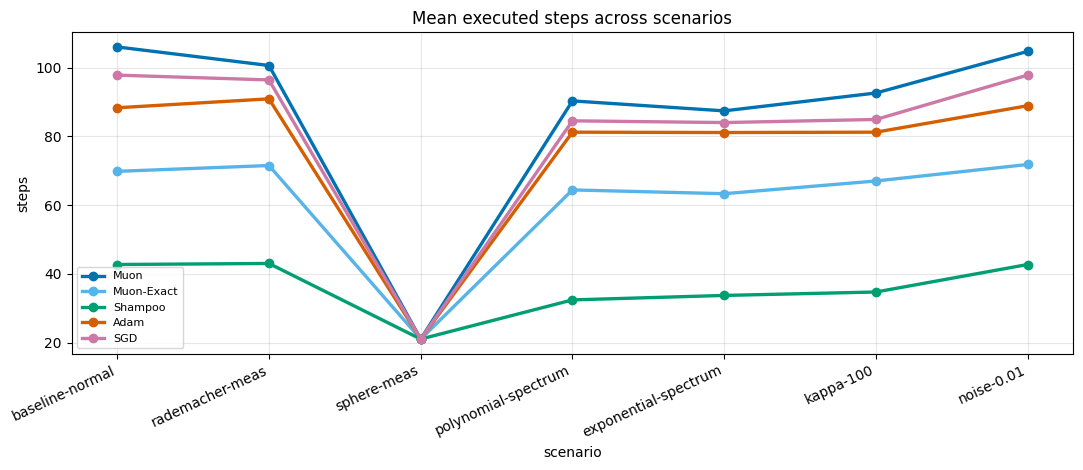

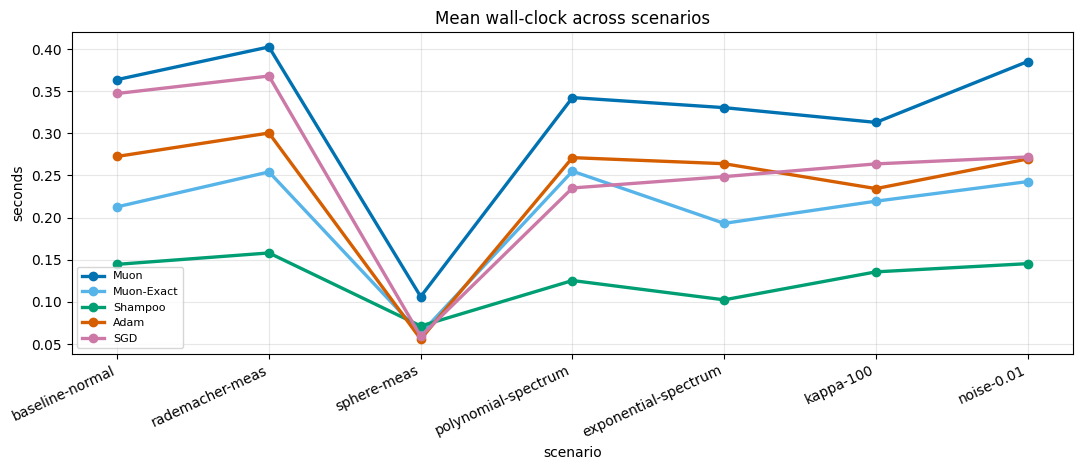

In [7]:
fig, ax = plotting.plot_scenario_metric(run_summary, "actual_steps", "Mean executed steps across scenarios", "steps")
show_figure(fig)

fig, ax = plotting.plot_scenario_metric(run_summary, "time_s", "Mean wall-clock across scenarios", "seconds")
show_figure(fig)


### Scenario Minimum Loss

This plot evaluates the best achieved value of the scenario-specific objective $f_s(X)$ from the Problem cell.

The horizontal axis is the ablation scenario and color is optimizer. The vertical value is the seed average of $\min_t f(X_t)$ within that scenario-method group. The linear plot is useful for large absolute failures; the log plot is the one to read when several methods all look close to zero on a linear scale.

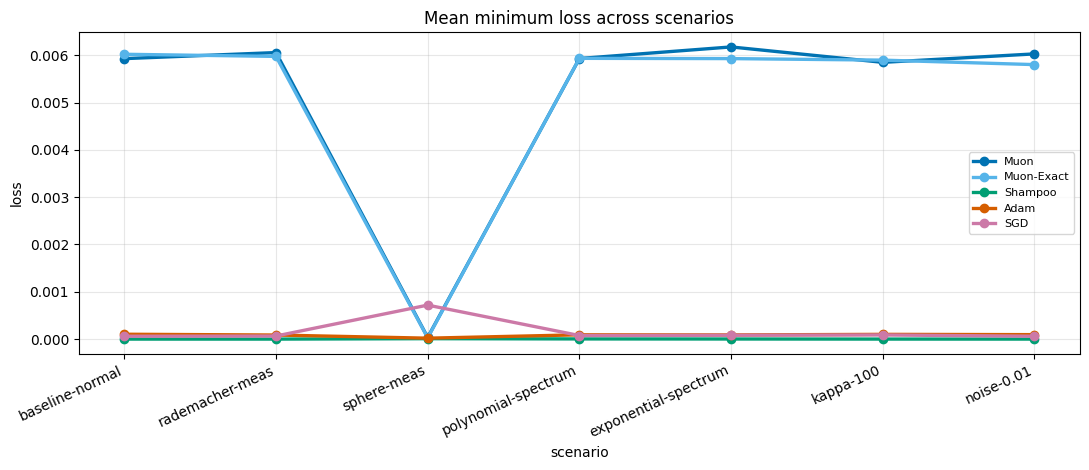

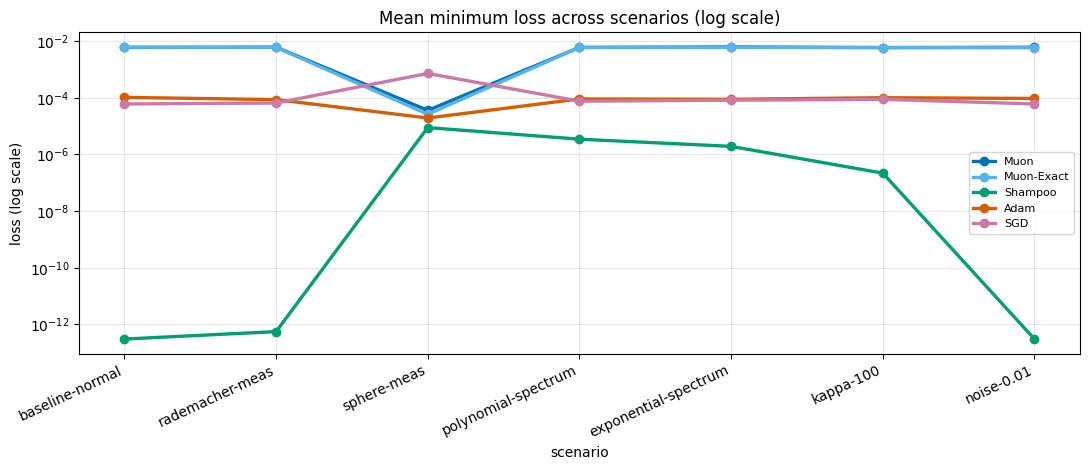

In [8]:
fig, ax = plotting.plot_scenario_metric(run_summary, "min_loss", "Mean minimum loss across scenarios", "loss")
show_figure(fig)

fig, ax = plotting.plot_scenario_metric(run_summary, "min_loss", "Mean minimum loss across scenarios", "loss", log_y=True)
show_figure(fig)


### Scenario Final Loss

This plot evaluates the endpoint of the same scenario-specific objective $f_s(X)$ from the Problem cell, which matters when an optimizer does not end at its best iterate.

This uses the same scenario-by-optimizer layout as the minimum-loss plot, but the vertical value is the endpoint loss $f(X_T)$ averaged over seeds. If final loss is much worse than minimum loss for a method, the method found a good iterate but did not end there. If both are bad, the scenario is genuinely hard for that optimizer under this step budget.

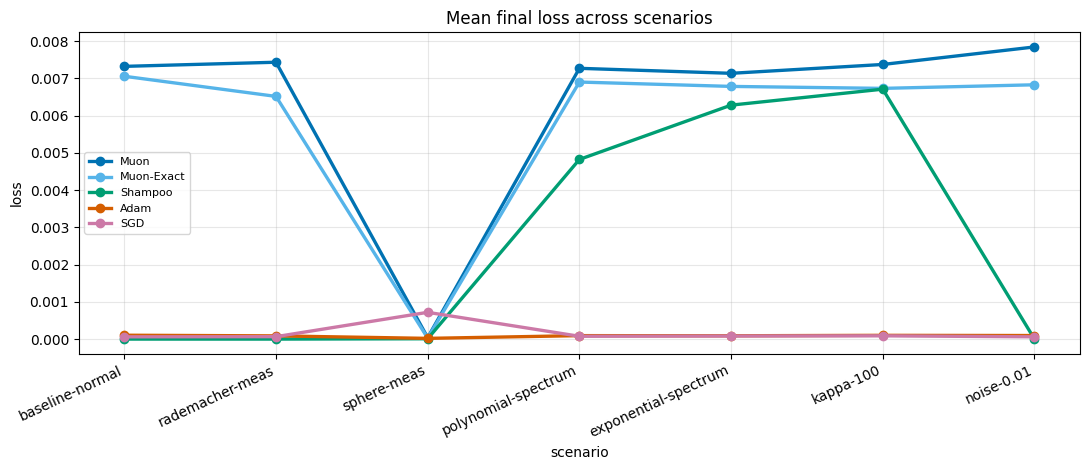

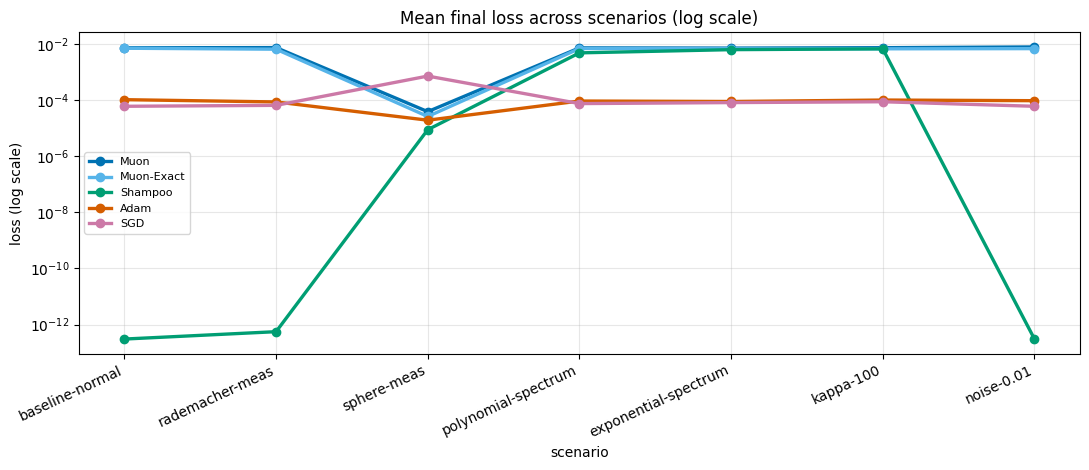

In [9]:
fig, ax = plotting.plot_scenario_metric(run_summary, "final_loss", "Mean final loss across scenarios", "loss")
show_figure(fig)

fig, ax = plotting.plot_scenario_metric(run_summary, "final_loss", "Mean final loss across scenarios", "loss", log_y=True)
show_figure(fig)


### Per-Scenario Metric Overview

Each figure now fixes one of the modeling assumptions introduced in the Problem cell, so the remaining comparison is optimizer behavior inside that scenario.

Each generated figure fixes one ablation scenario. The shared plotting helper still places $d$ on the horizontal axis, but in this notebook $d=60$ is fixed, so the meaningful dimensions are panel and color: panels are executed steps, wall-clock seconds, and minimum loss; color is optimizer. Read these figures as per-scenario compact summaries rather than as dimension-scaling plots.

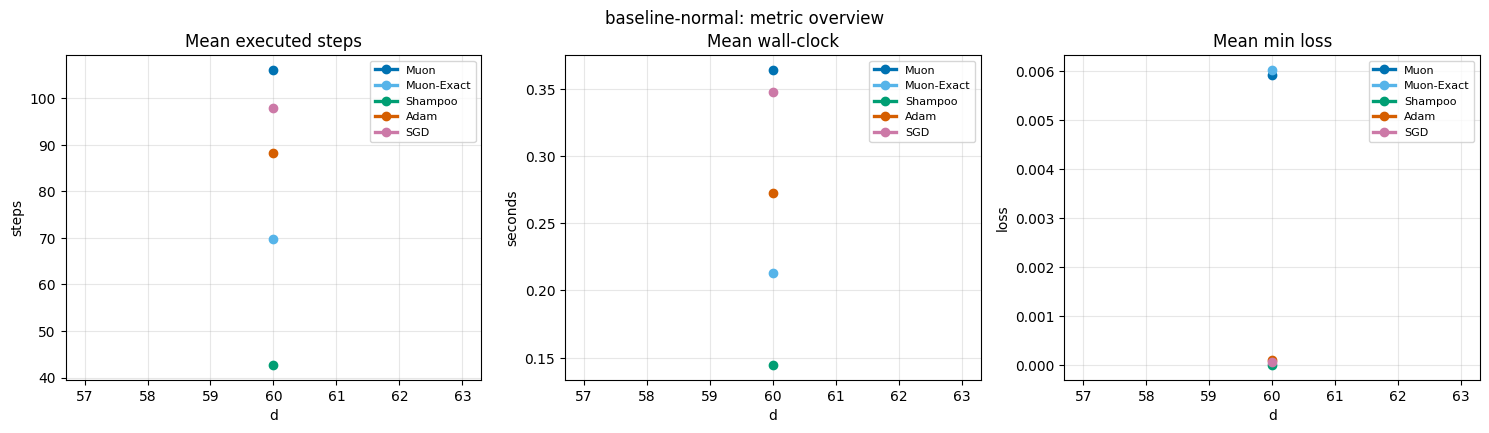

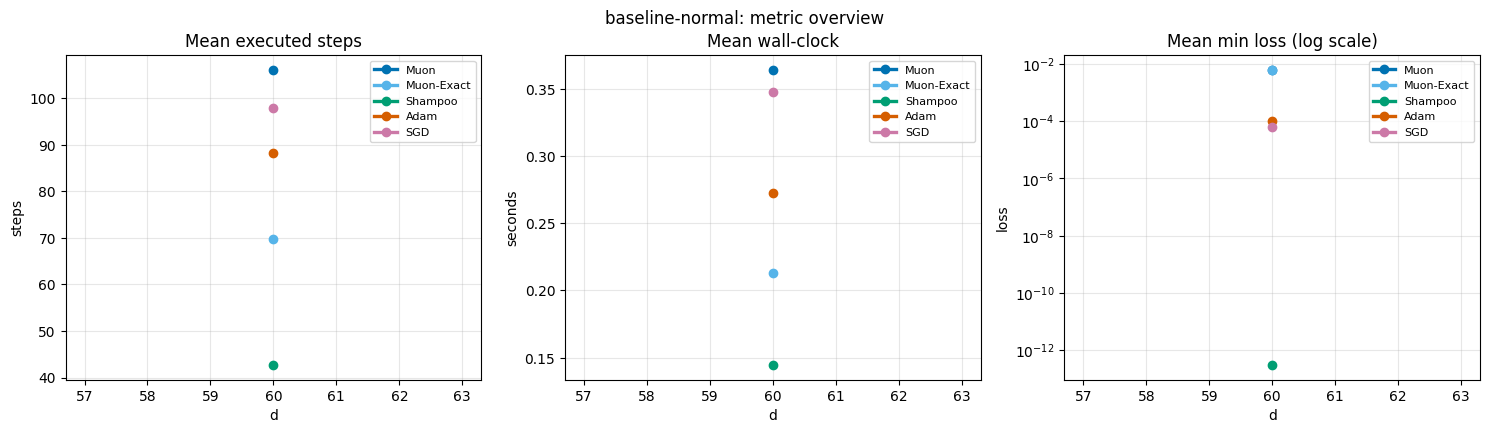

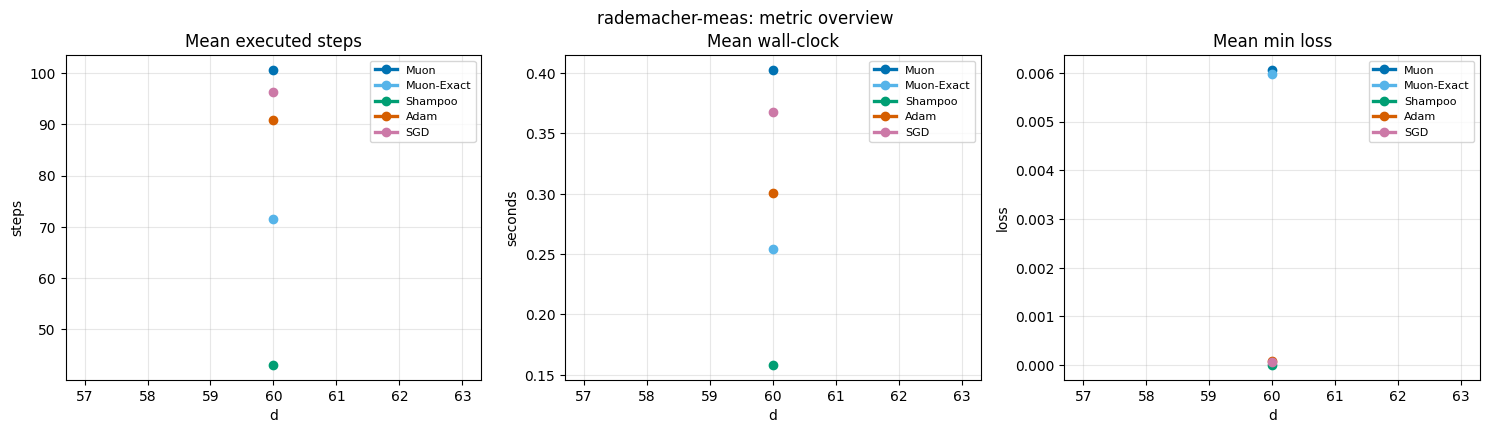

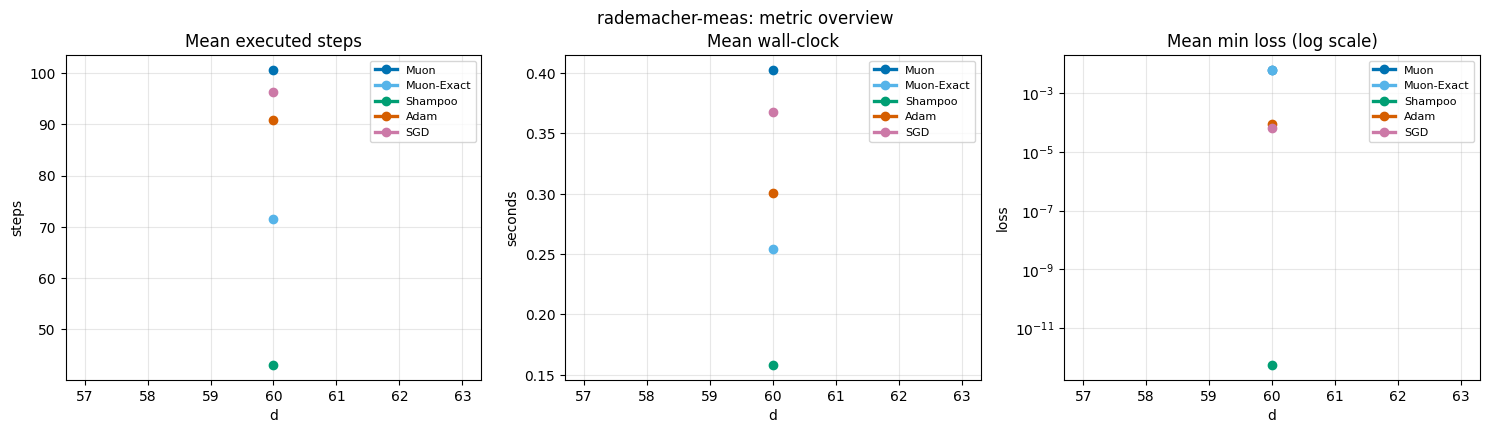

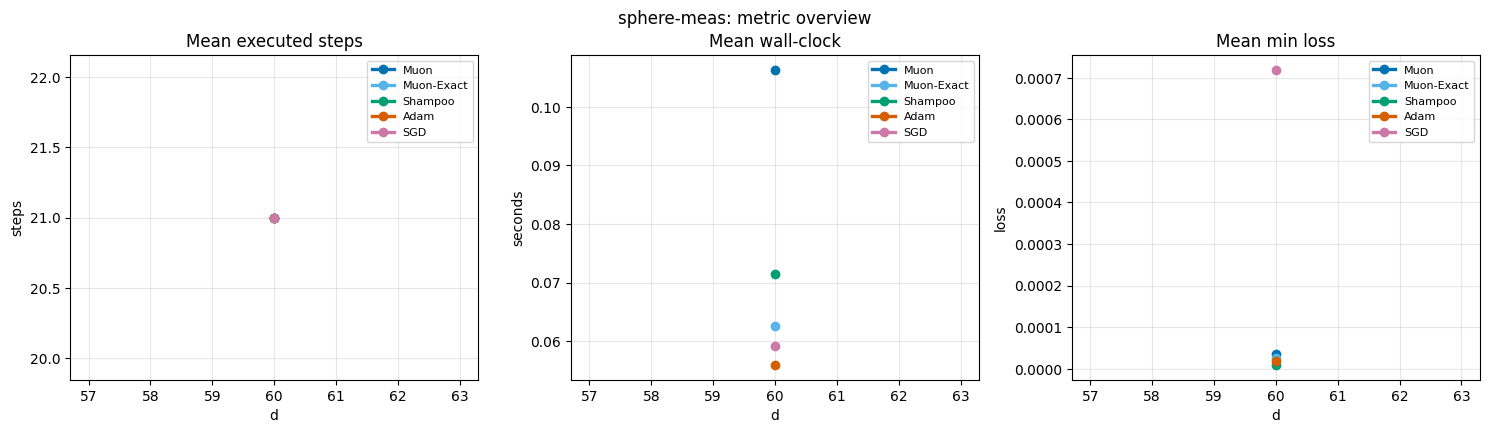

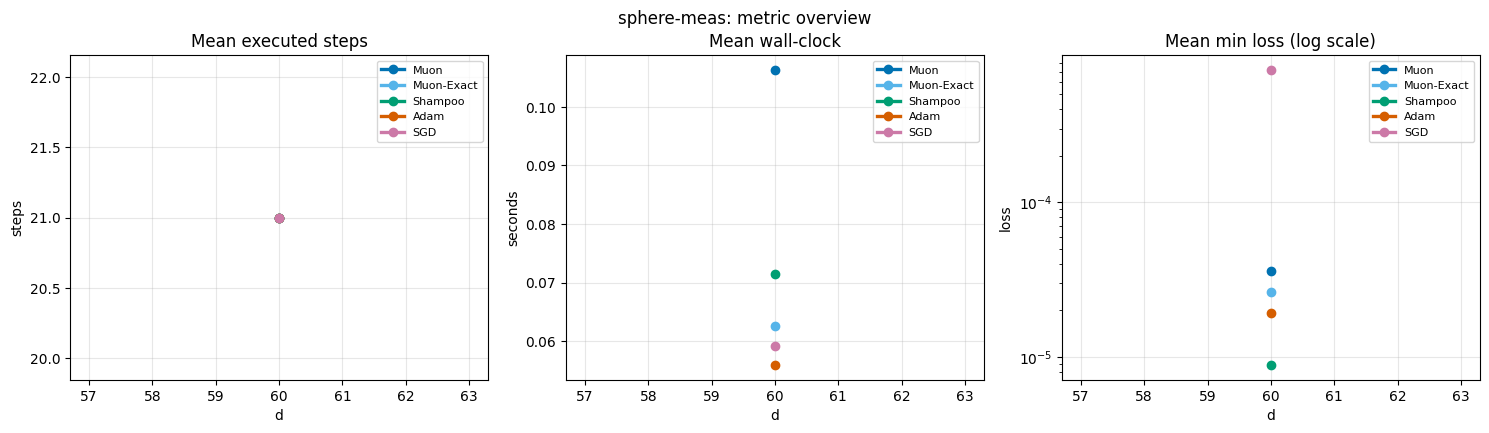

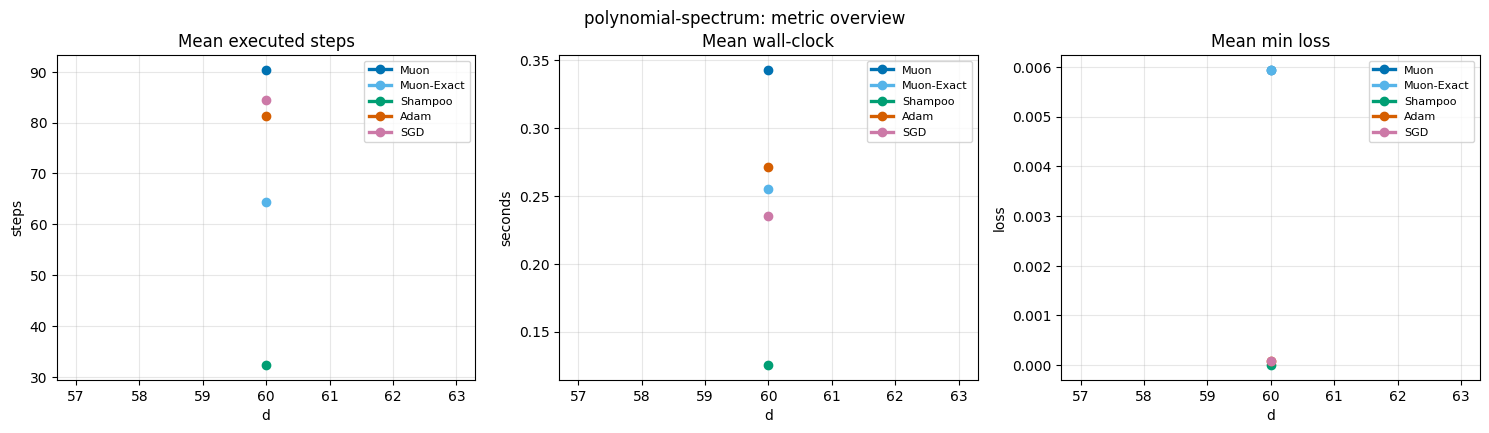

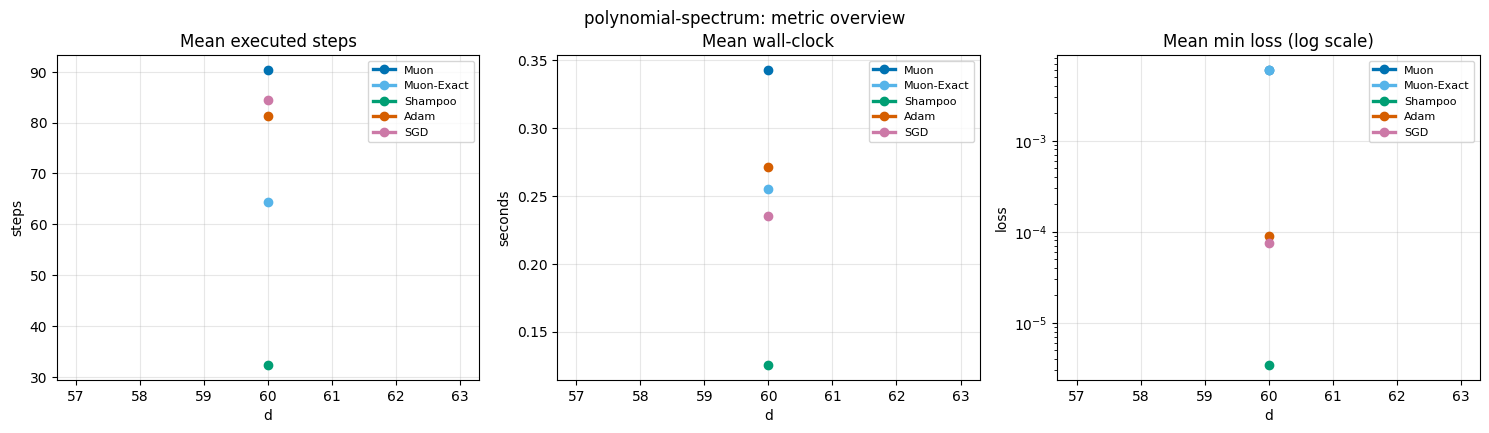

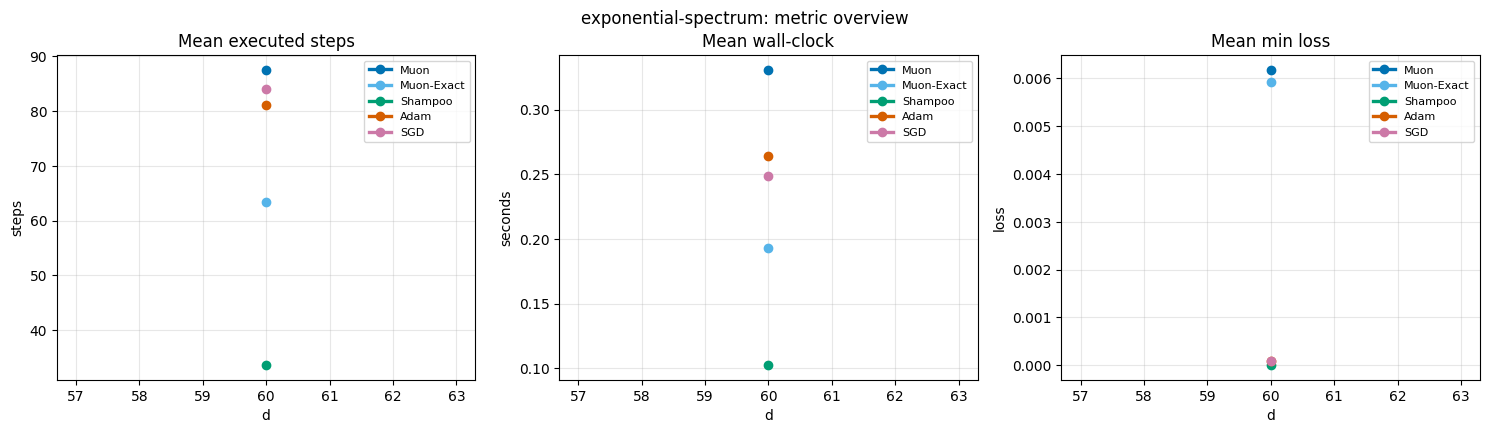

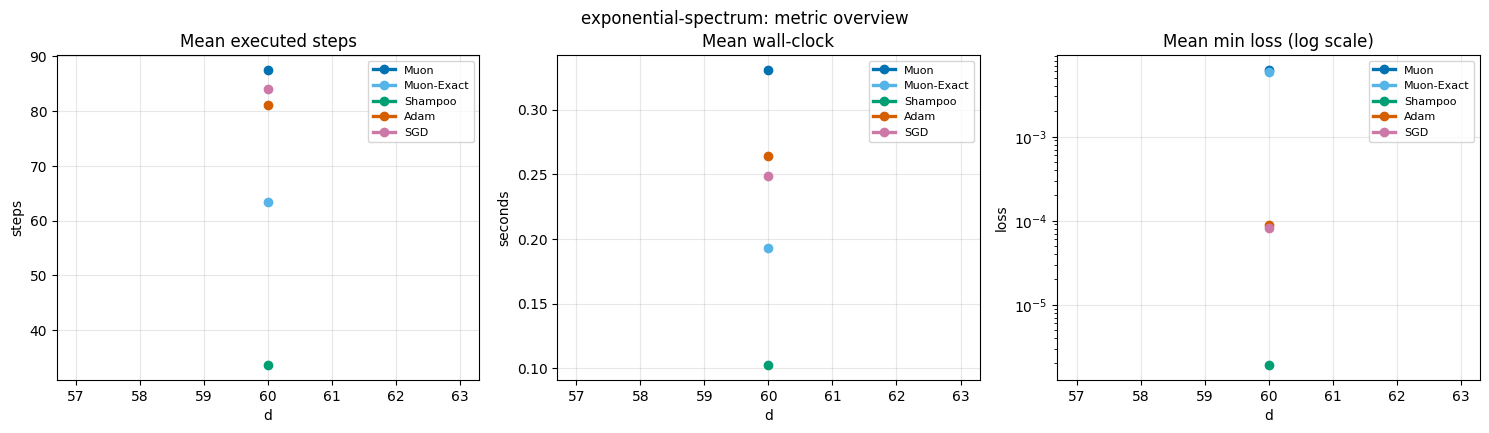

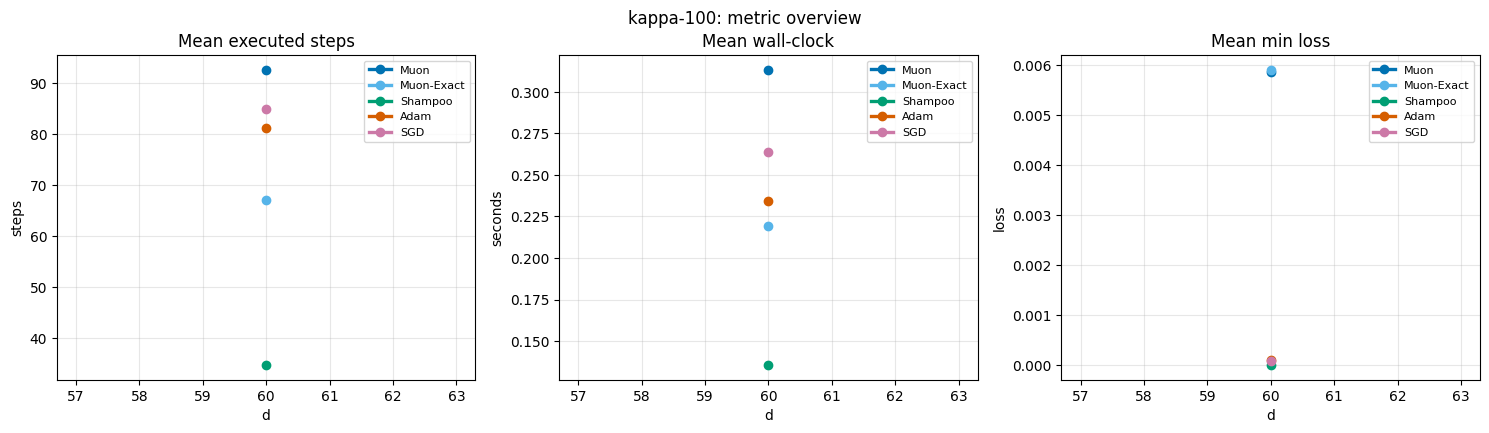

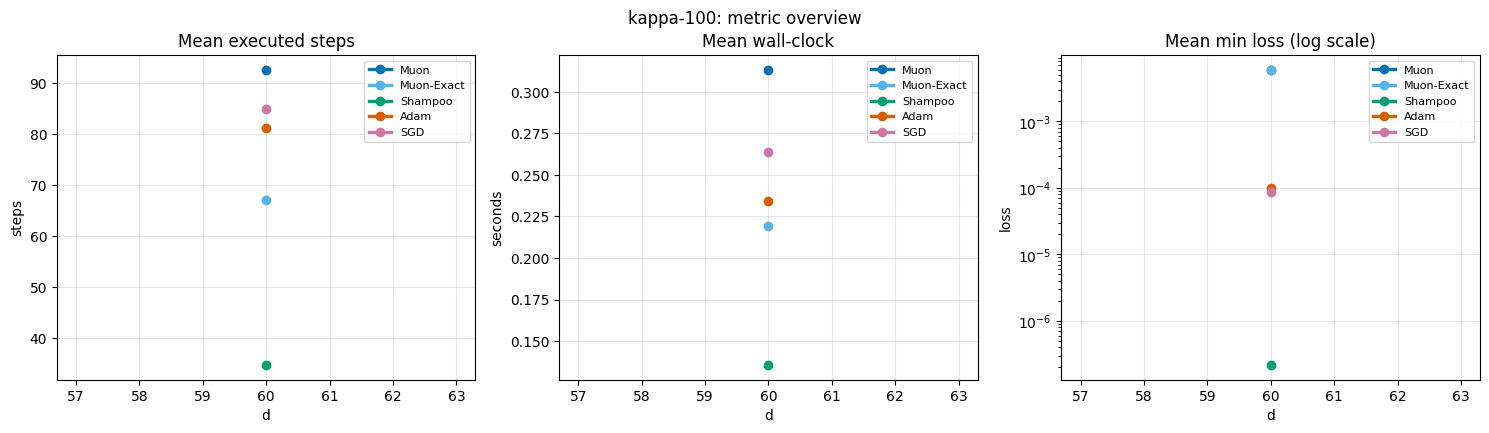

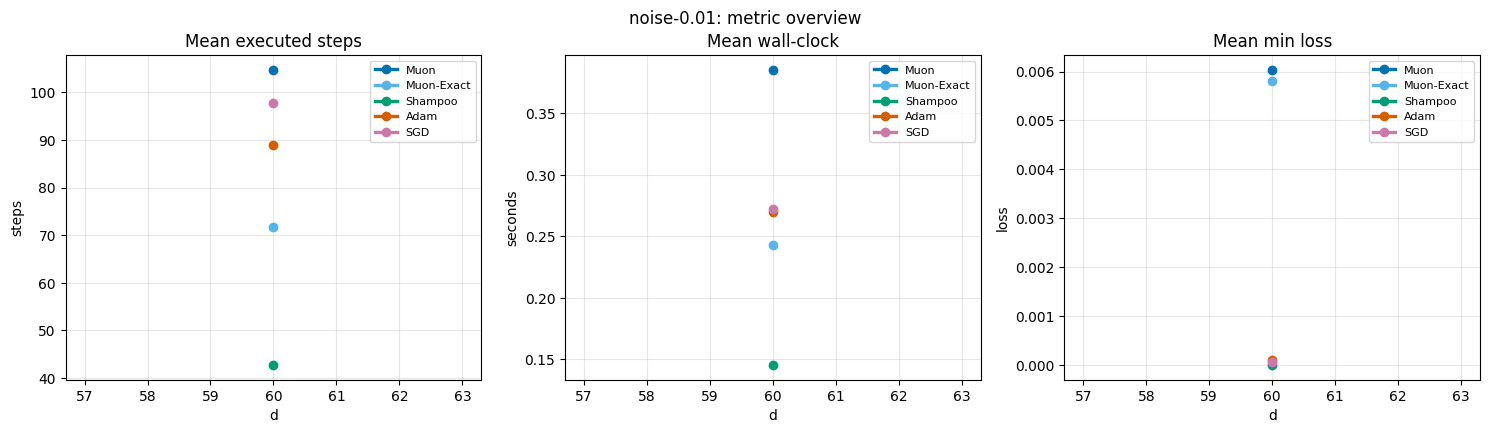

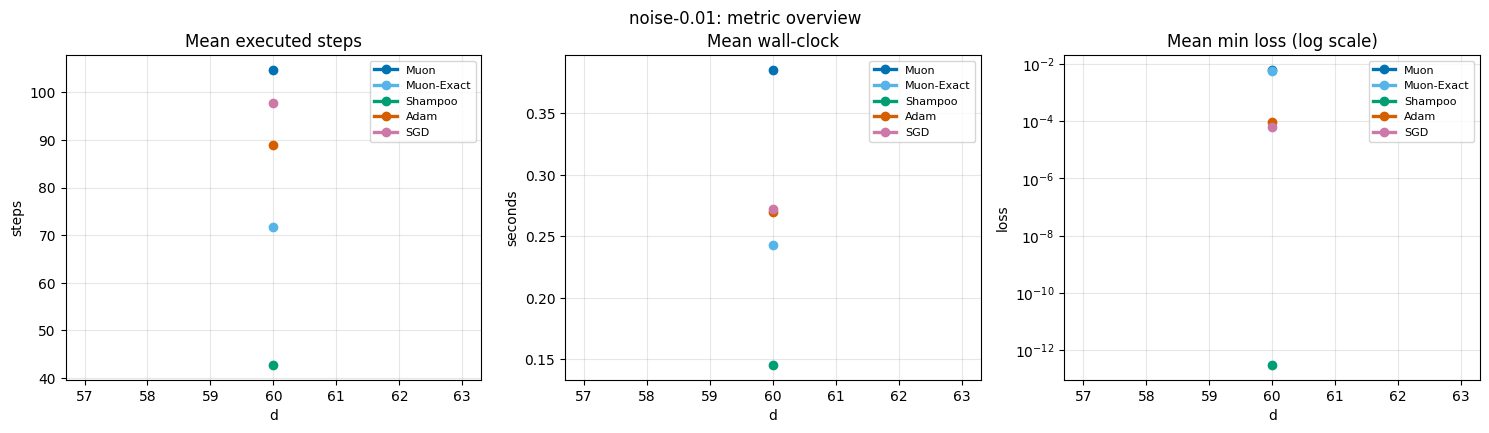

In [10]:
for scenario in SCENARIO_ORDER:
    sub_summary = run_summary[run_summary["scenario"] == scenario]
    for loss_log_y in (False, True):
        fig, axes = plotting.plot_metric_overview(sub_summary, loss_log_y=loss_log_y)
        fig.suptitle(f"{scenario}: metric overview", y=1.02)
        show_figure(fig)


### Per-Scenario Algorithm Trajectories

These curves show how each optimizer minimizes the Problem cell’s $f_s(X)$ after choosing one concrete scenario $s$.

Each generated figure fixes one ablation scenario. The horizontal axis is optimization step $t$, the vertical axis is seed-mean Matrix Sensing loss $\mathbb{E}_{\mathrm{seed}}[f(X_t)]$, and each colored line is one optimizer. The linear version shows early absolute decrease; the log version is better for comparing long-run convergence and accuracy floors.

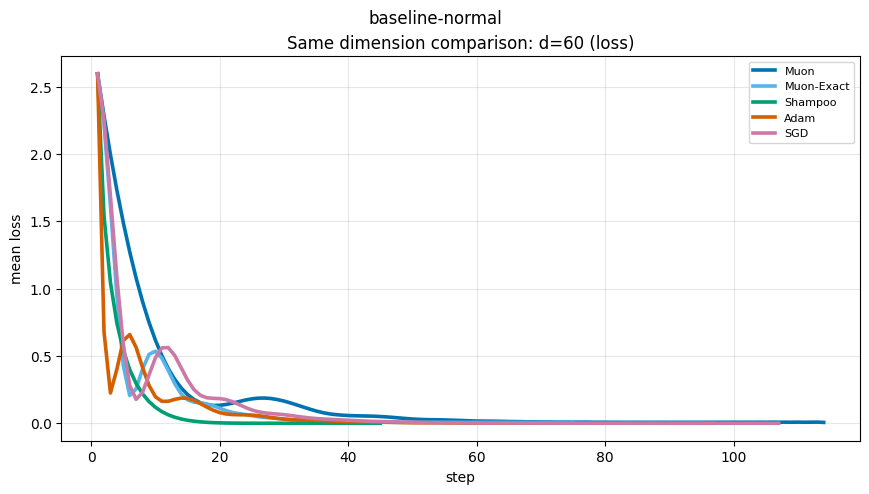

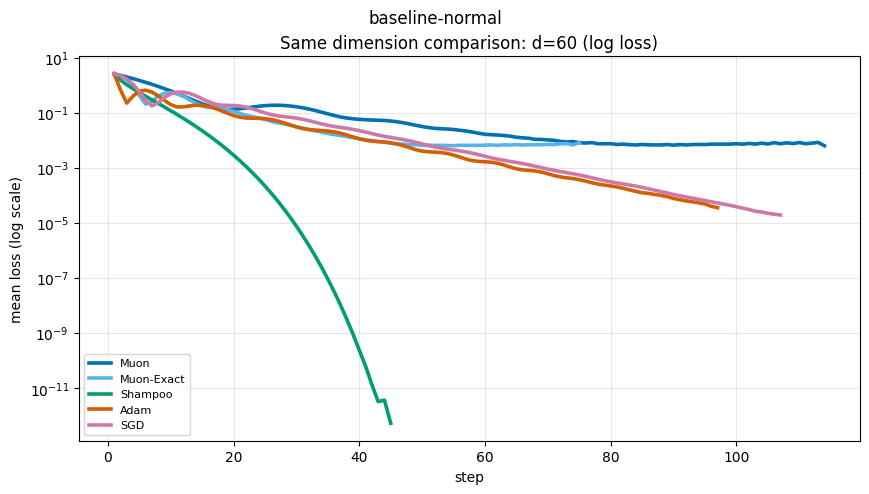

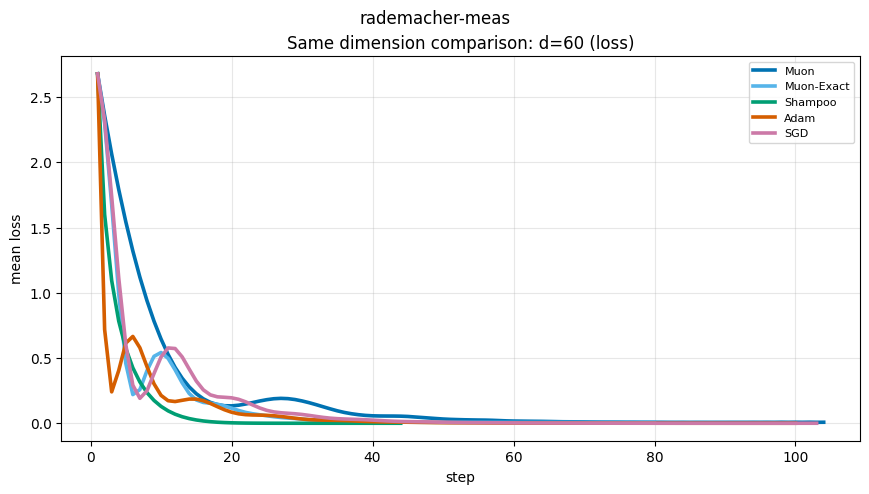

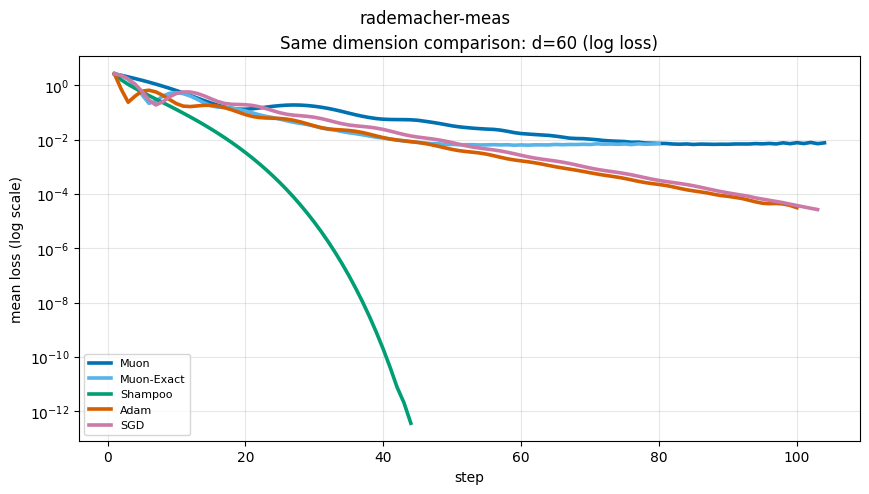

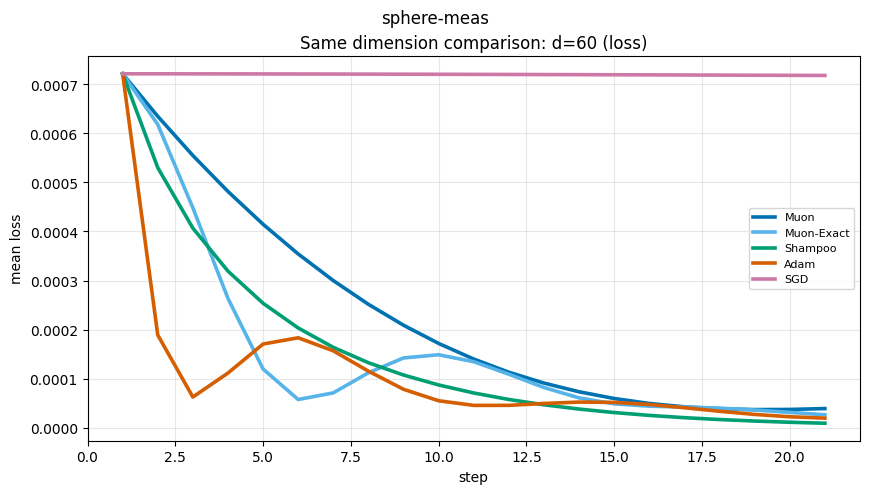

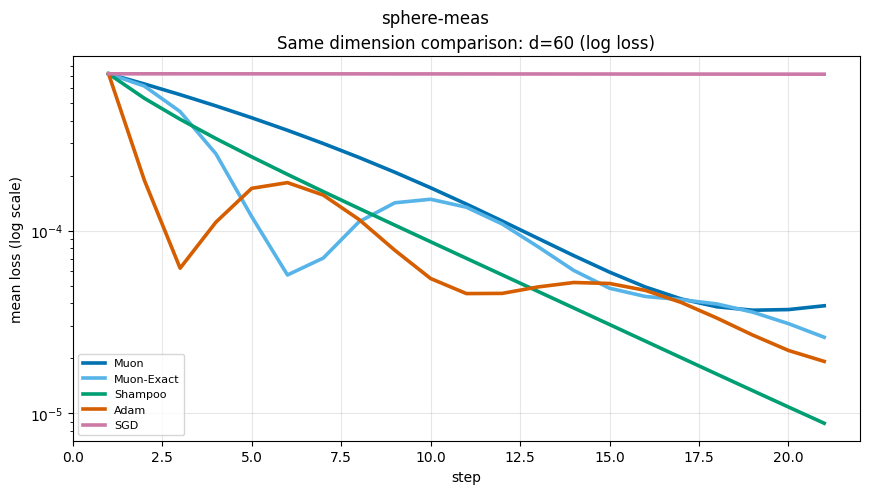

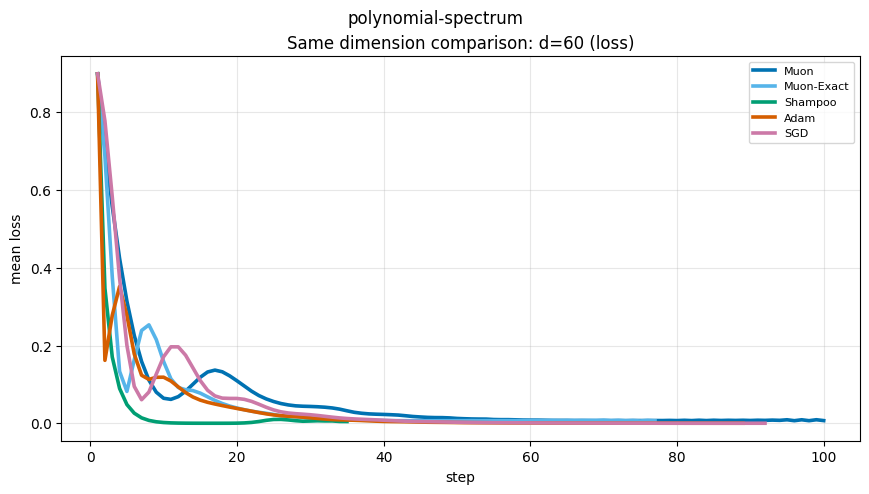

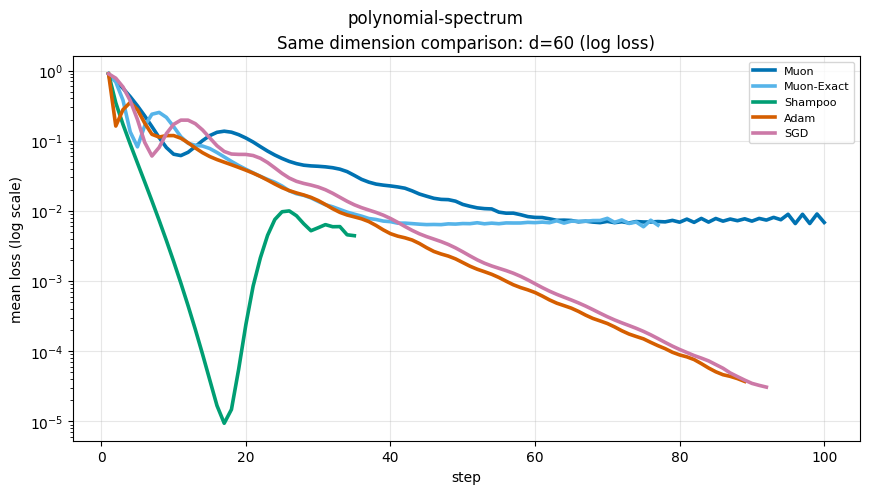

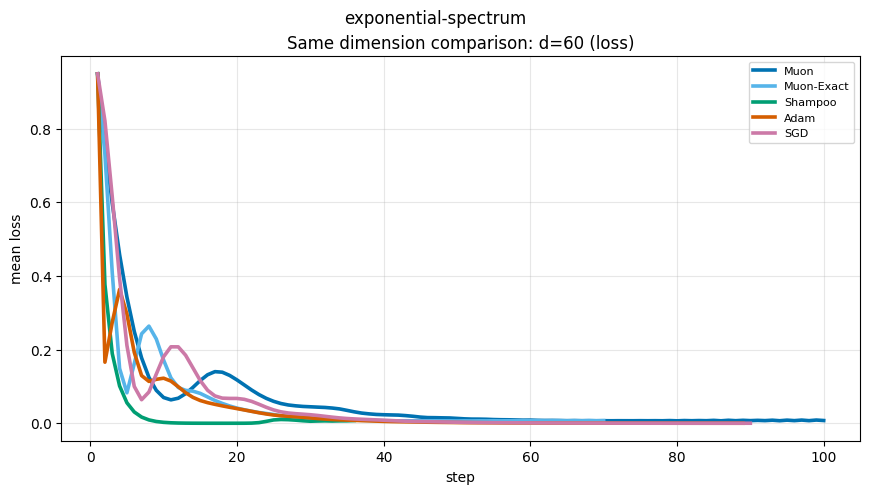

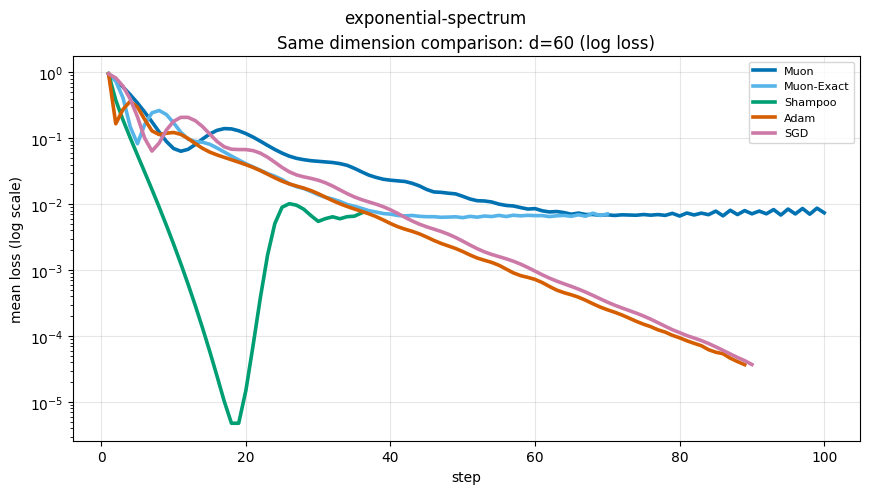

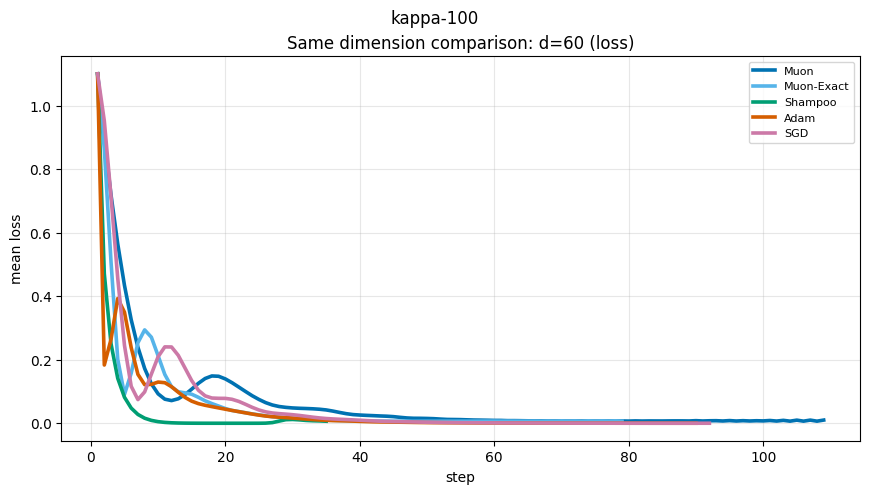

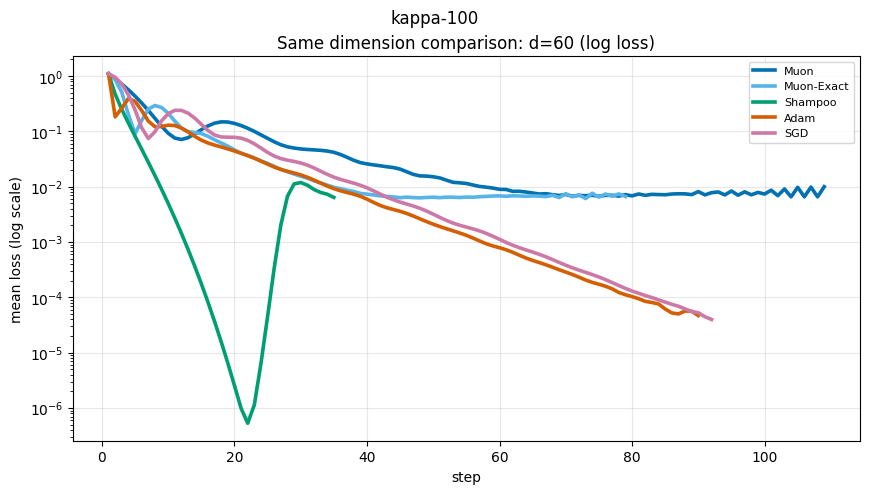

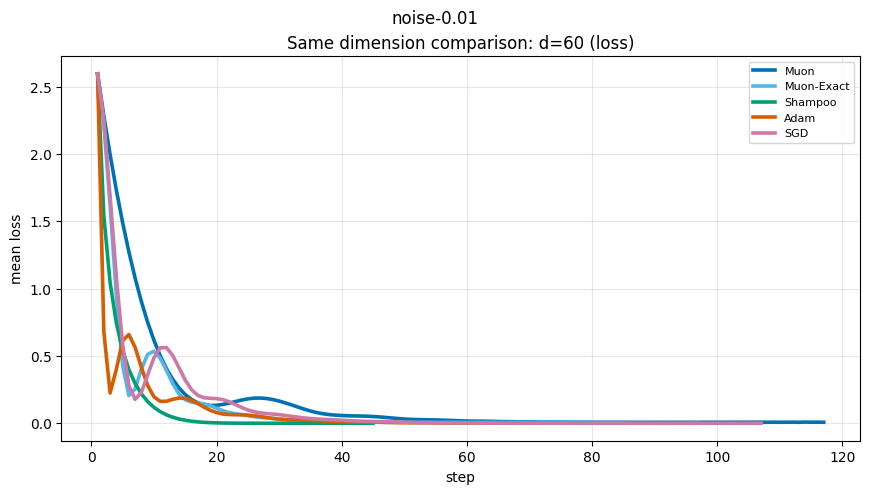

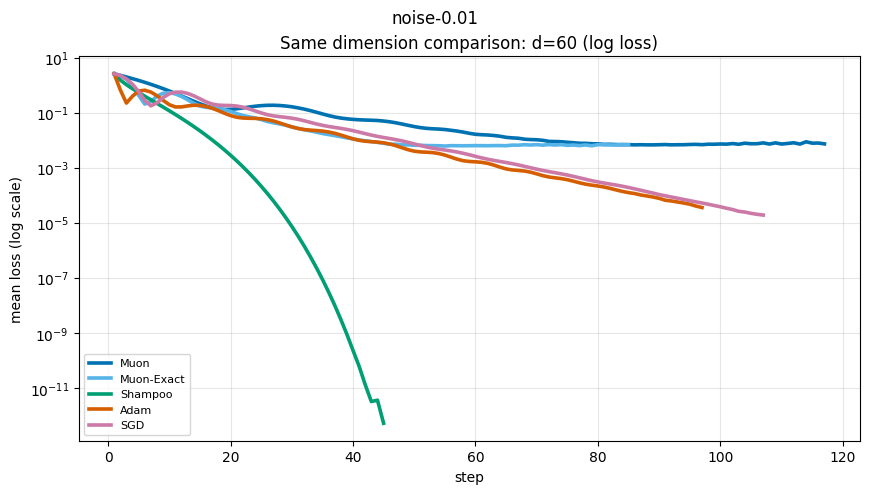

In [11]:
for scenario in SCENARIO_ORDER:
    sub_runs = runs[runs["scenario"] == scenario]
    scenario_trajectories = trajectories_from(sub_runs)
    for log_y in (False, True):
        fig, ax = plotting.plot_algorithms_for_dimension(scenario_trajectories, BASE_SPEC["d"], log_y=log_y)
        fig.suptitle(scenario, y=1.02)
        show_figure(fig)


### Per-Scenario Seed Variability

The Problem cell’s scenarios still contain random targets, measurements, and initializations; this plot shows whether conclusions for a scenario are seed-stable.

Each generated figure fixes one ablation scenario and expands the seed dimension instead of averaging it away. The horizontal axis is step $t$, the vertical axis is individual-run loss $f(X_t)$, and each faint line is one seed for one optimizer. Use this to identify scenarios where a method is inconsistent even if its mean trajectory looks acceptable.

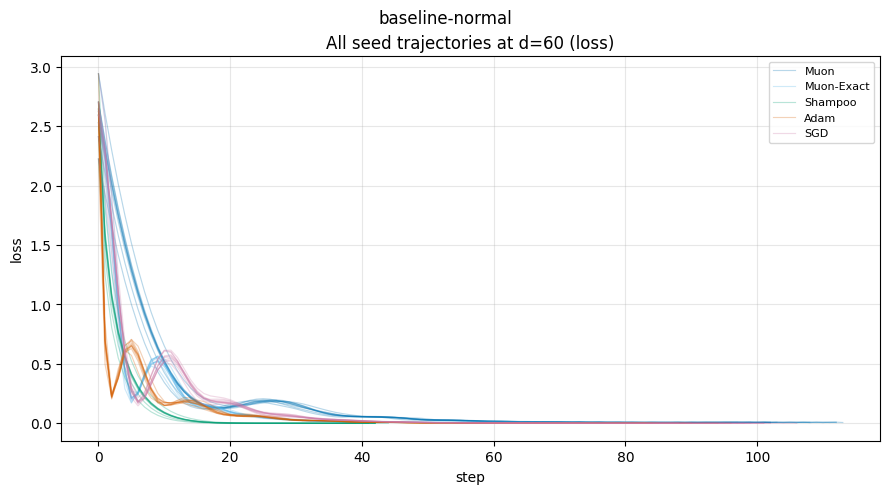

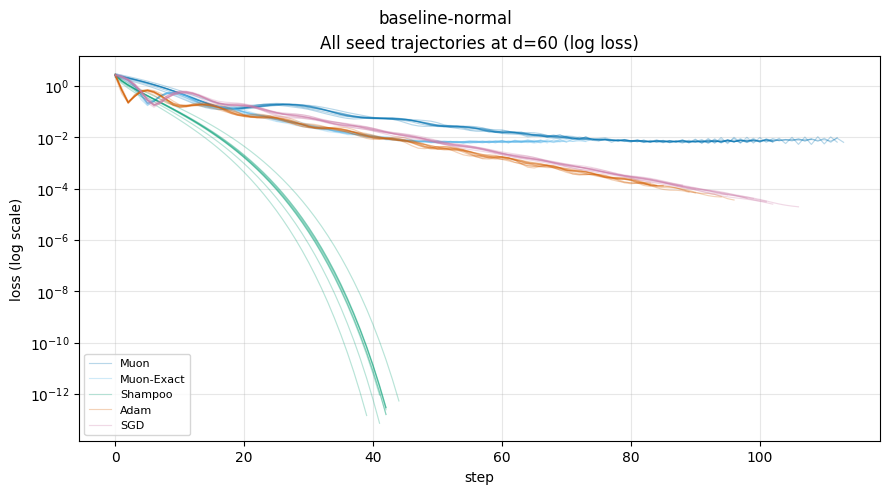

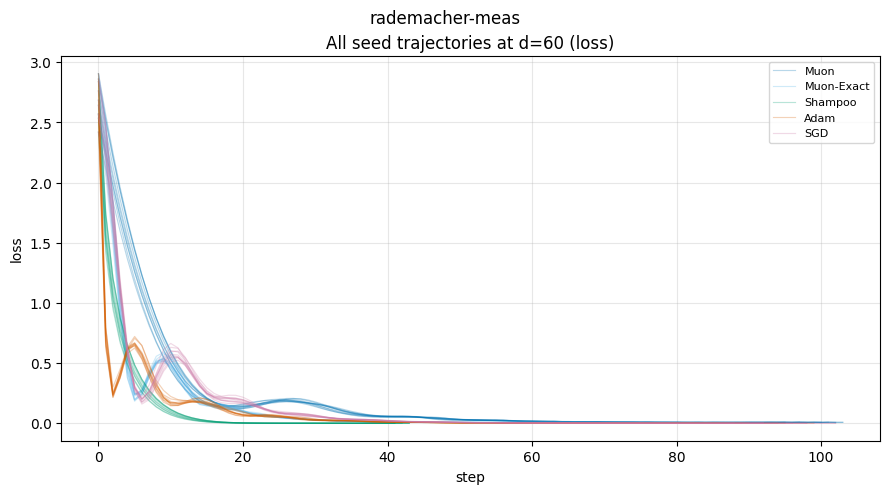

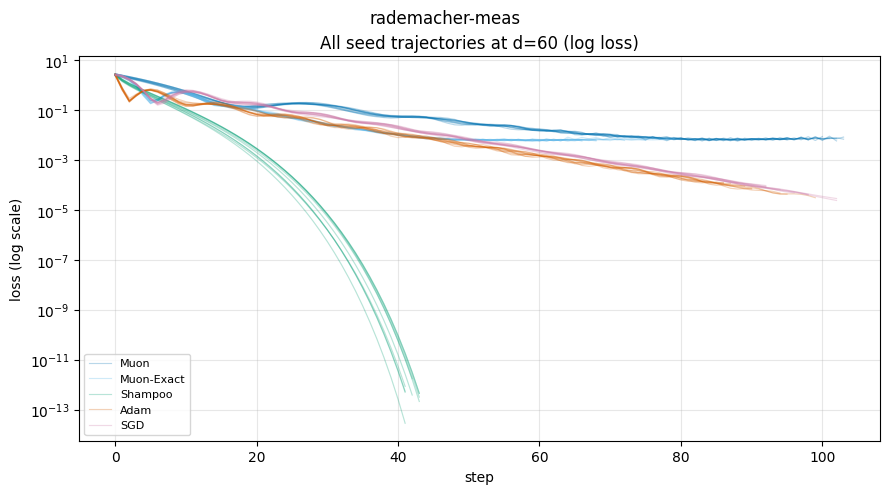

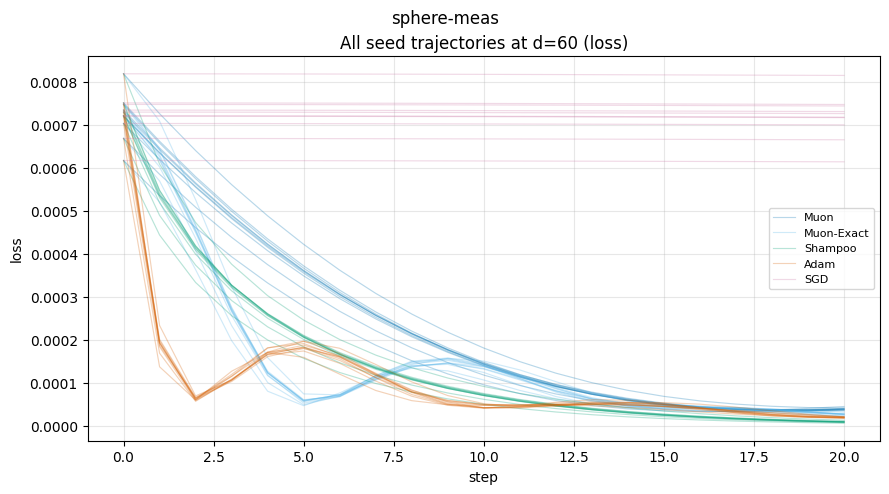

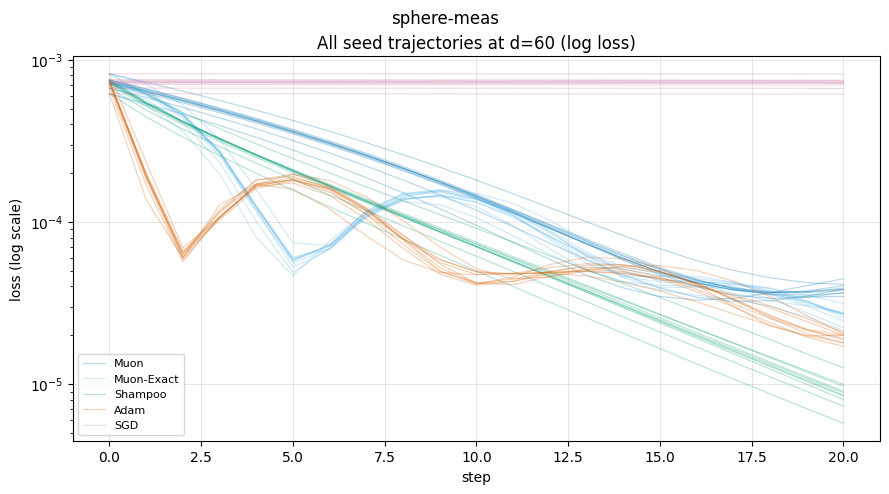

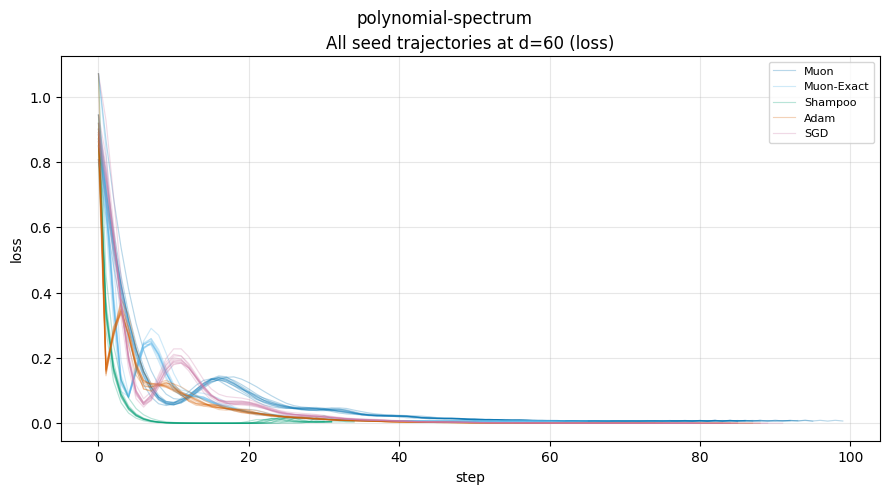

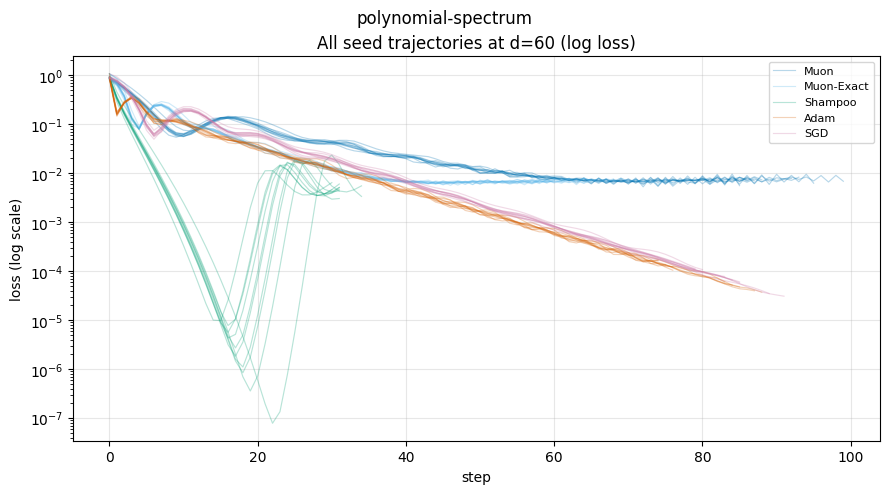

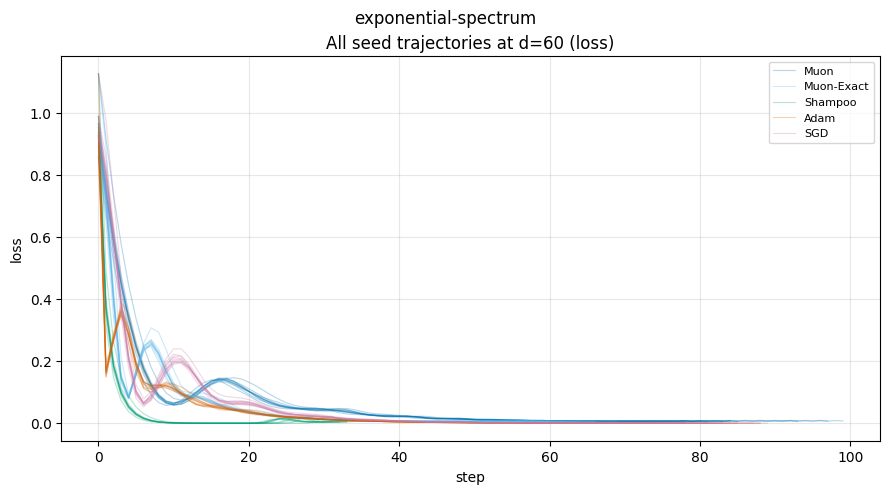

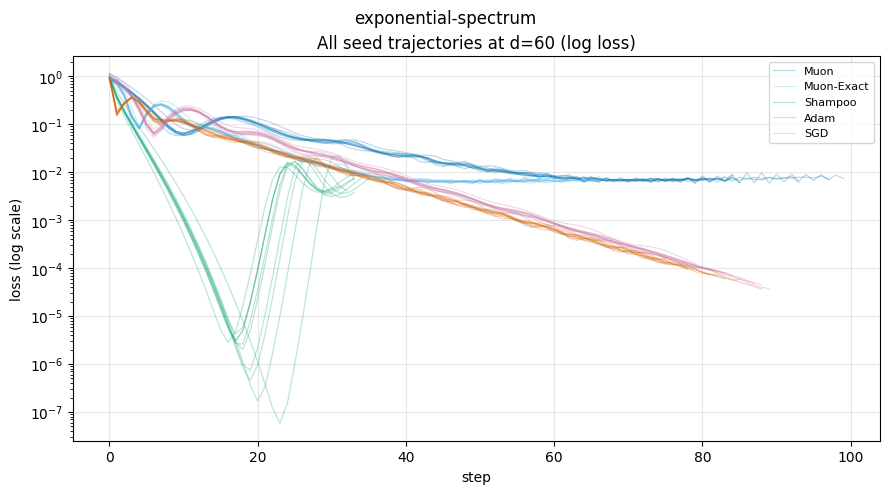

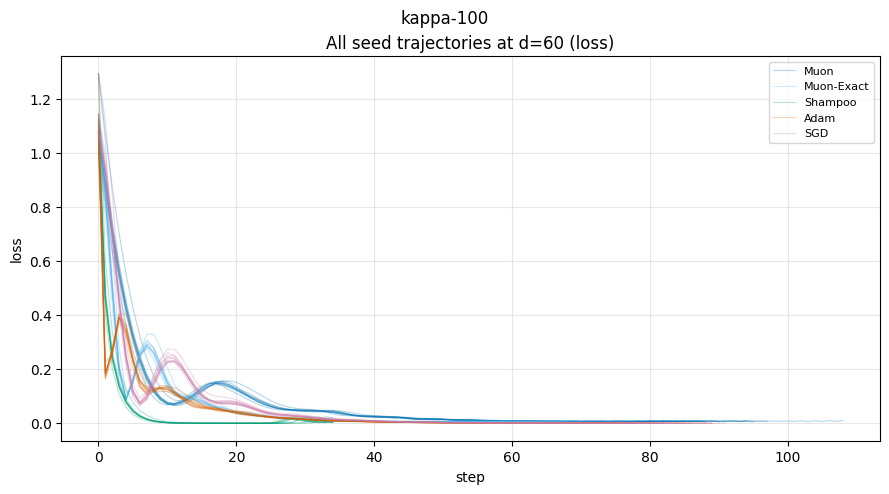

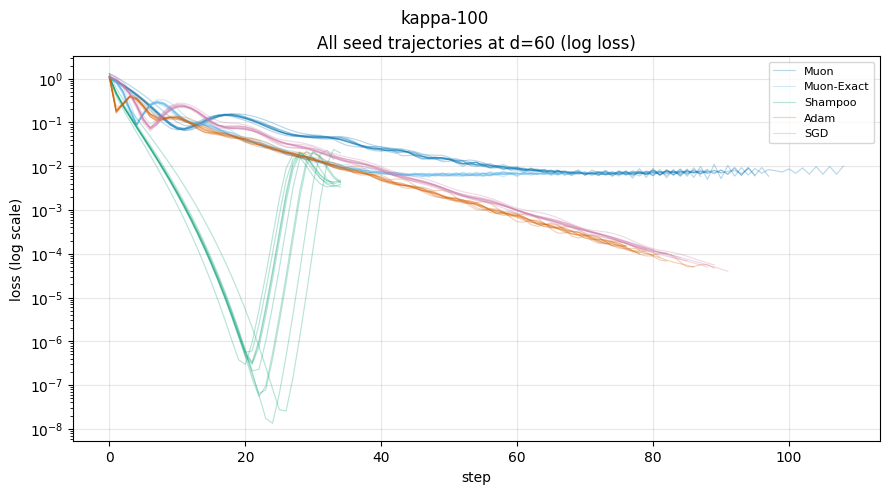

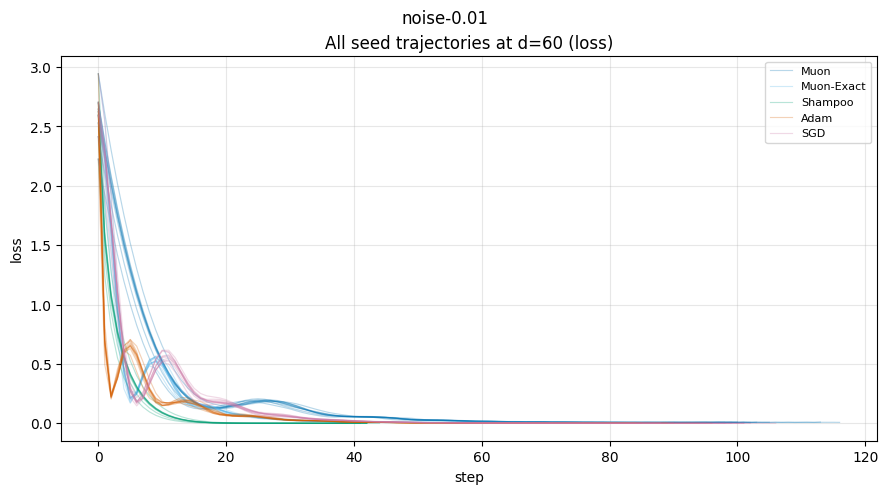

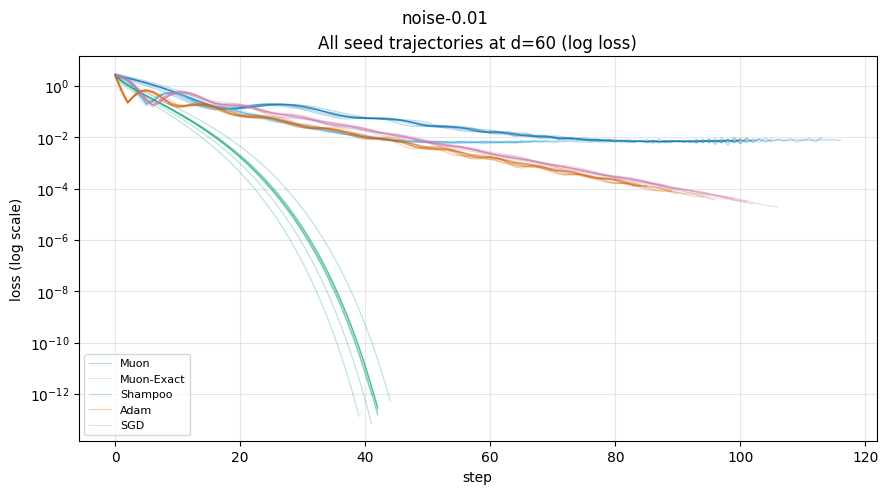

In [12]:
for scenario in SCENARIO_ORDER:
    sub_runs = runs[runs["scenario"] == scenario]
    scenario_trajectories = trajectories_from(sub_runs)
    for log_y in (False, True):
        fig, ax = plotting.plot_seed_variability_for_dimension(scenario_trajectories, BASE_SPEC["d"], log_y=log_y)
        fig.suptitle(scenario, y=1.02)
        show_figure(fig)


### Conclusion

In [13]:
def conclusion_markdown(run_summary):
    max_steps = int(run_summary["iters"].sum())
    actual_steps = int(run_summary["actual_steps"].sum())
    stopped = int(run_summary["stopped_early"].sum())
    lines = [
        "### Result Summary",
        "",
        f"- Scenarios: `{len(SCENARIO_ORDER)}`",
        f"- Runs: `{len(run_summary)}`",
        f"- Methods: `{', '.join(sorted(run_summary['algo'].unique()))}`",
        f"- Max iterations per run: `{int(run_summary['iters'].iloc[0])}`",
        f"- Max optimizer-step budget: `{max_steps}`",
        f"- Executed optimizer steps: `{actual_steps}` (`{max_steps - actual_steps}` skipped by early stopping)",
        f"- Early-stopped runs: `{stopped}/{len(run_summary)}`",
        "",
    ]
    for scenario in SCENARIO_ORDER:
        sub = scenario_summary[scenario_summary["scenario"] == scenario]
        fewest_steps = sub.loc[sub["actual_steps_mean"].idxmin()]
        best_time = sub.loc[sub["time_s_mean"].idxmin()]
        best_loss = sub.loc[sub["min_loss_mean"].idxmin()]
        lines.append(
            f"- {scenario}: fewest executed steps is `{fewest_steps.algo}` at `{fewest_steps.actual_steps_mean:.1f}` steps; "
            f"fastest wall-clock is `{best_time.algo}` at `{best_time.time_s_mean:.3f}s`; "
            f"lowest min_loss is `{best_loss.algo}` at `{best_loss.min_loss_mean:.3e}`."
        )
    lines.append("")
    lines.append("This ablation identifies which assumptions in E01 make the problem easy or hard: measurement distribution, spectrum shape, conditioning, and observation noise.")
    lines.append("Use this notebook to explain long runtimes when a scenario both converges slowly and uses expensive optimizer updates.")
    return "\n".join(lines)


IPython.display.display(IPython.display.Markdown(conclusion_markdown(run_summary)))


### Result Summary

- Scenarios: `7`
- Runs: `350`
- Methods: `Adam, Muon, Muon-Exact, SGD, Shampoo`
- Max iterations per run: `2000`
- Max optimizer-step budget: `700000`
- Executed optimizer steps: `23806` (`676194` skipped by early stopping)
- Early-stopped runs: `350/350`

- baseline-normal: fewest executed steps is `Shampoo` at `42.7` steps; fastest wall-clock is `Shampoo` at `0.145s`; lowest min_loss is `Shampoo` at `3.062e-13`.
- rademacher-meas: fewest executed steps is `Shampoo` at `43.0` steps; fastest wall-clock is `Shampoo` at `0.158s`; lowest min_loss is `Shampoo` at `5.608e-13`.
- sphere-meas: fewest executed steps is `Muon` at `21.0` steps; fastest wall-clock is `Adam` at `0.056s`; lowest min_loss is `Shampoo` at `8.831e-06`.
- polynomial-spectrum: fewest executed steps is `Shampoo` at `32.4` steps; fastest wall-clock is `Shampoo` at `0.125s`; lowest min_loss is `Shampoo` at `3.441e-06`.
- exponential-spectrum: fewest executed steps is `Shampoo` at `33.7` steps; fastest wall-clock is `Shampoo` at `0.102s`; lowest min_loss is `Shampoo` at `1.919e-06`.
- kappa-100: fewest executed steps is `Shampoo` at `34.7` steps; fastest wall-clock is `Shampoo` at `0.136s`; lowest min_loss is `Shampoo` at `2.181e-07`.
- noise-0.01: fewest executed steps is `Shampoo` at `42.7` steps; fastest wall-clock is `Shampoo` at `0.145s`; lowest min_loss is `Shampoo` at `3.054e-13`.

This ablation identifies which assumptions in E01 make the problem easy or hard: measurement distribution, spectrum shape, conditioning, and observation noise.
Use this notebook to explain long runtimes when a scenario both converges slowly and uses expensive optimizer updates.